# Implementation of XGboost in classification problems

**Project** : The prediction task is to specify whether a person makes over $50K a year or not.

# Step 0 : Importing important dependencies

In [56]:
# Essential Libraries

import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

# Model specific 
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler



# Step 1 : Data collection and Data understanding 

In [22]:
df = pd.read_csv('D:\Robotics\Learn Machine Learning with RoboZe\XGboost in Depth\data\Adult.csv')

Data understanding

In [23]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [24]:
df.shape

(32561, 15)

In [59]:
df['workclass'].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [26]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [27]:
df['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [28]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [63]:
df = pd.get_dummies(df)
df.head()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia,income_<=50K,income_>50K
0,90,77053,9,0,4356,40,True,False,False,False,...,False,False,False,False,False,True,False,False,True,False
1,82,132870,9,0,4356,18,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
2,66,186061,10,0,4356,40,True,False,False,False,...,False,False,False,False,False,True,False,False,True,False
3,54,140359,4,0,3900,40,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
4,41,264663,10,0,3900,40,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False


In [66]:
df = pd.get_dummies(df)

In [67]:
df.head()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia,income_<=50K,income_>50K
0,90,77053,9,0,4356,40,True,False,False,False,...,False,False,False,False,False,True,False,False,True,False
1,82,132870,9,0,4356,18,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
2,66,186061,10,0,4356,40,True,False,False,False,...,False,False,False,False,False,True,False,False,True,False
3,54,140359,4,0,3900,40,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
4,41,264663,10,0,3900,40,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False


In [29]:
cols =df.columns

In [30]:
cols

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')

<Axes: >

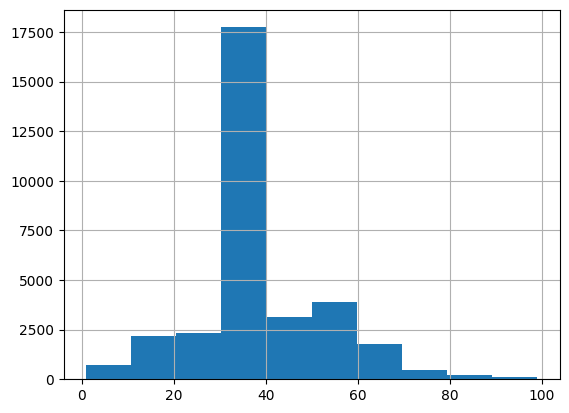

In [31]:
df['hours.per.week'].hist()

# Data visualization 

# Data analysis Summary 

## Splitting the data

In [32]:
features = ['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country']

In [33]:
target = 'income'

In [68]:
x = df[features]
y = df[target]

KeyError: "['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country'] not in index"

In [44]:
y.value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [47]:
y = y.map({'<=50K':0 , '>50K':1})

In [48]:
y.value_counts()

income
0    24720
1     7841
Name: count, dtype: int64

In [51]:
x_train , x_test , y_train , y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [52]:
x_train.shape

(26048, 14)

In [53]:
x_test.shape

(6513, 14)

## Scalling the data 

In [57]:
sc = StandardScaler()

In [58]:
sc.fit(x_train)

ValueError: could not convert string to float: 'Private'

# Training the model 

In [54]:
help(XGBClassifier)

Help on class XGBClassifier in module xgboost.sklearn:

class XGBClassifier(sklearn.base.ClassifierMixin, XGBModel)
 |  XGBClassifier(*, objective: Union[str, xgboost.sklearn._SklObjWProto, Callable[[Any, Any], Tuple[numpy.ndarray, numpy.ndarray]], NoneType] = 'binary:logistic', **kwargs: Any) -> None
 |  
 |  Implementation of the scikit-learn API for XGBoost classification.
 |  See :doc:`/python/sklearn_estimator` for more information.
 |  
 |  Parameters
 |  ----------
 |  
 |      n_estimators : Optional[int]
 |          Number of boosting rounds.
 |  
 |      max_depth :  typing.Optional[int]
 |  
 |          Maximum tree depth for base learners.
 |  
 |      max_leaves : typing.Optional[int]
 |  
 |          Maximum number of leaves; 0 indicates no limit.
 |  
 |      max_bin : typing.Optional[int]
 |  
 |          If using histogram-based algorithm, maximum number of bins per feature
 |  
 |      grow_policy : typing.Optional[str]
 |  
 |          Tree growing policy.
 |  
 |   

In [40]:
xgb_clf = XGBClassifier(n_estimators = 500 ,
                         learning_rate = 0.05,
                         eval_metric = 'logloss',
                         use_label_encoder = False,
                         early_stopping_rounds = 5, 
                         n_jobs = -1
                         
                         )

In [55]:
xgb_clf.fit(x_train , y_train , 
            eval_set = [(x_test , y_test)],
            verbose = False)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:workclass: object, education: object, marital.status: object, occupation: object, relationship: object, race: object, sex: object, native.country: object